# Checkpoint 5 - Statistical Computing with R & Python + Machine Learning & Modelling

Integrantes: Arthur Costa Donaire (RM571283) · Felipe Pereira de Jesus (RM573263) · Giovanna Pereira de Oliveira (RM570989) · Gustavo Paiva Silva (RM572249) · Maria Eduarda Soares Lopes e Souza (RM572612)

---

## Objetivo
Integrar análise estatística descritiva e probabilística com modelagem não supervisionada, utilizando o dataset **Wines**. Na parte de Machine Learning, o algoritmo K-means será utilizado para agrupar vinhos com características semelhantes.

## Dataset
- **Fonte:** [Wine Dataset for Clustering (Kaggle)](https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering). O arquivo `wine.csv` (ou `wines.csv`) deve estar na mesma pasta deste notebook; no Google Colab, o notebook pede o upload do arquivo.
- **Conteúdo:** 178 vinhos e 14 colunas: `Wine` (classe original: 1, 2 ou 3) e 13 medidas químicas quantitativas (`Alcohol`, `Malic.acid`, `Ash`, `Acl`, `Mg`, `Phenols`, `Flavanoids`, `Nonflavanoid.phenols`, `Proanth`, `Color.int`, `Hue`, `OD` e `Proline`).

## Estrutura do notebook
1. **Statistical Computing** (Python): (a) tabela de frequências e gráficos, (b) medidas descritivas e quartis, (c) distribuição de probabilidade e cálculos.
2. **Machine Learning & Modelling**: K-means com padronização, escolha de k por Elbow e Silhouette e análise dos clusters.
3. **Conclusão**, limitações e próximos passos.


In [1]:
# ===== Bibliotecas =====
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Paleta única para todos os gráficos: uma cor por variável analisada
CORES = {'Alcohol': '#7A1F3A', 'Malic.acid': '#C28A2E'}
COR_TRACO = '#2B2024'

pd.set_option('display.max_columns', None)

# ===== Carregamento dos dados =====
# Fonte: https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering
# O enunciado cita 'wines.csv' e o Kaggle traz 'wine.csv': aceitamos os dois nomes.
CAMINHO = next((p for p in ['wine.csv', 'wines.csv'] if os.path.exists(p)), None)
if CAMINHO is None:
    try:
        # No Google Colab: abre um seletor para enviar o arquivo do seu computador
        from google.colab import files
        print('Selecione o arquivo wine.csv (ou wines.csv)...')
        CAMINHO = list(files.upload().keys())[0]
    except ImportError:
        raise FileNotFoundError('wine.csv não encontrado. Baixe o dataset no Kaggle e salve na mesma pasta do notebook.')
df = pd.read_csv(CAMINHO)
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
print('Valores nulos no dataset:', df.isnull().sum().sum())   # 0 -> não é preciso tratar dados ausentes
display(df.head())

Linhas: 178 | Colunas: 14
Valores nulos no dataset: 0


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Statistical Computing with R & Python

Foram escolhidas duas variáveis quantitativas:

- **Alcohol**: teor alcoólico dos vinhos.
- **Malic.acid**: concentração de ácido málico.

A escolha é intencional: permite comparar uma variável de **menor dispersão relativa** (Alcohol) com outra **mais heterogênea e assimétrica** (Malic.acid), e ver como cada técnica (frequências, medidas descritivas, probabilidade) se comporta nos dois casos.

### 1.1 (a) Visualização dos dados: tabela de frequências e gráfico


### Alcohol


,Frequência,Frequência relativa (%),Frequência acumulada,Freq. rel. acumulada (%)
Alcohol,,,,
"(11.026, 11.452]",3,1.69,3,1.69
"(11.452, 11.874]",15,8.43,18,10.11
"(11.874, 12.297]",23,12.92,41,23.03
"(12.297, 12.719]",28,15.73,69,38.76
"(12.719, 13.141]",28,15.73,97,54.49
"(13.141, 13.563]",30,16.85,127,71.35
"(13.563, 13.986]",29,16.29,156,87.64
"(13.986, 14.408]",20,11.24,176,98.88
"(14.408, 14.83]",2,1.12,178,100.00


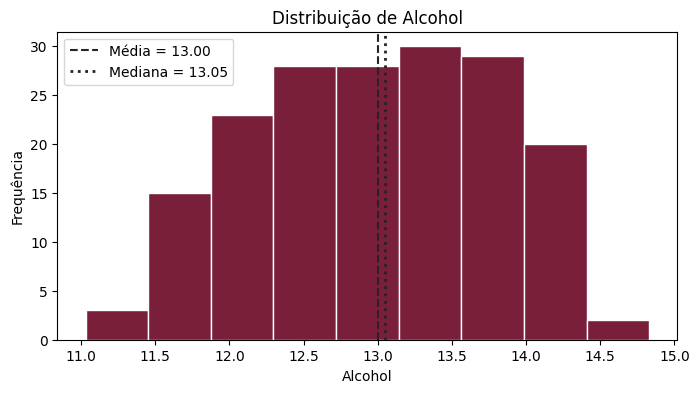


### Malic.acid


,Frequência,Frequência relativa (%),Frequência acumulada,Freq. rel. acumulada (%)
Malic.acid,,,,
"(0.735, 1.302]",21,11.80,21,11.80
"(1.302, 1.864]",68,38.20,89,50.00
"(1.864, 2.427]",25,14.04,114,64.04
"(2.427, 2.989]",16,8.99,130,73.03
"(2.989, 3.551]",16,8.99,146,82.02
"(3.551, 4.113]",17,9.55,163,91.57
"(4.113, 4.676]",8,4.49,171,96.07
"(4.676, 5.238]",4,2.25,175,98.31
"(5.238, 5.8]",3,1.69,178,100.00


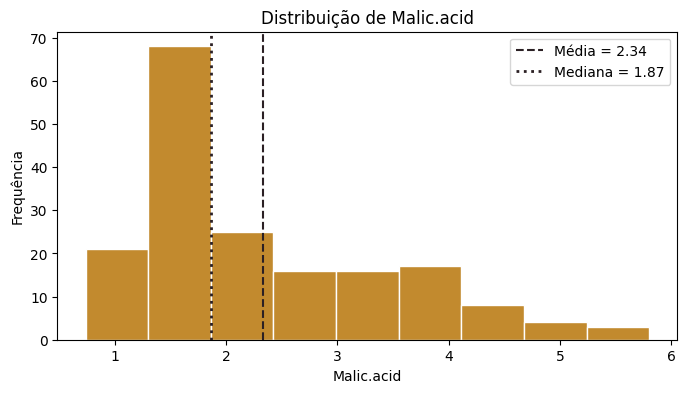

In [2]:
# ===== (a) Tabela de distribuição de frequências + histograma =====
def tabela_frequencia(serie, bins=9):
    # Classes de mesma amplitude (pd.cut). 9 classes é coerente com a regra de
    # Sturges para n = 178: 1 + log2(178) = 8,5 -> 9 classes.
    classes = pd.cut(serie, bins=bins)
    freq = classes.value_counts().sort_index()
    out = pd.DataFrame({'Frequência': freq})
    out['Frequência relativa (%)'] = out['Frequência'] / len(serie) * 100
    out['Frequência acumulada'] = out['Frequência'].cumsum()
    out['Freq. rel. acumulada (%)'] = out['Frequência relativa (%)'].cumsum()
    return out

for col in ['Alcohol', 'Malic.acid']:
    print(f'\n### {col}')
    display(tabela_frequencia(df[col]).round(2))
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=9, edgecolor='white', color=CORES[col])
    plt.axvline(df[col].mean(), color=COR_TRACO, linestyle='--', label=f'Média = {df[col].mean():.2f}')
    plt.axvline(df[col].median(), color=COR_TRACO, linestyle=':', linewidth=2, label=f'Mediana = {df[col].median():.2f}')
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

# Interpretação (Alcohol):
#  - As 4 classes centrais (12,30 a 13,99) reúnem 115 dos 178 vinhos (64,6%); as classes
#    extremas têm só 3 e 2 vinhos.
#  - Média (13,00) ≈ mediana (13,05): distribuição aproximadamente simétrica e concentrada.
# Interpretação (Malic.acid):
#  - A classe 1,30–1,86 concentra 68 vinhos (38,2%) e 50% dos vinhos (89 de 178) estão
#    abaixo de 1,86; depois a frequência cai devagar até 5,80 (cauda longa à direita).
#  - Média (2,34) > mediana (1,865): assimetria positiva (à direita).

### Interpretação das distribuições

- **Alcohol** apresenta maior concentração dos valores em torno de 13, com as quatro classes centrais reunindo 64,6% dos vinhos e média praticamente igual à mediana: distribuição **aproximadamente simétrica** e de baixa dispersão relativa.
- **Malic.acid** é mais espalhada e possui **assimetria à direita**: a classe de 1,30 a 1,86 sozinha tem 68 vinhos (38,2%), metade da amostra está abaixo de 1,86 e há uma cauda longa até 5,80. A média (2,34) fica acima da mediana (1,865).

### 1.2 (b) Análise descritiva: tendência central, dispersão e quartis

In [3]:
# ===== (b) Medidas de tendência central, dispersão e separatrizes (quartis) =====
def resumo_descritivo(serie):
    q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
    return pd.Series({
        # Tendência central
        'Média': serie.mean(),
        'Mediana': serie.median(),
        'Moda': serie.mode().iloc[0],
        # Dispersão (variância e desvio padrão amostrais, ddof = 1)
        'Mínimo': serie.min(),
        'Máximo': serie.max(),
        'Amplitude': serie.max() - serie.min(),
        'Variância': serie.var(),
        'Desvio padrão': serie.std(),
        'Coef. variação (%)': serie.std() / serie.mean() * 100,   # compara escalas diferentes
        # Forma da distribuição
        'Assimetria (skew)': serie.skew(),
        # Separatrizes
        'Q1': q1, 'Q2': q2, 'Q3': q3,
        'IQR': q3 - q1
    })

resumo = pd.concat({
    'Alcohol': resumo_descritivo(df['Alcohol']),
    'Malic.acid': resumo_descritivo(df['Malic.acid'])
}, axis=1)
display(resumo.round(4))

# Interpretação:
#  - Alcohol: média ≈ mediana e assimetria ≈ 0 (-0,05) -> simétrica; CV = 6,24% -> baixa
#    dispersão relativa.
#  - Malic.acid: média > mediana e assimetria positiva (1,04) -> cauda à direita; CV = 47,82%
#    -> heterogeneidade quase 8 vezes maior que a de Alcohol.
#  - O desvio padrão absoluto (0,81 x 1,12) esconde essa diferença; o CV corrige o efeito de
#    escala e é a medida certa para comparar as duas variáveis.
#  - Quartis: 50% dos vinhos têm Alcohol entre 12,36 e 13,68 (IQR = 1,32) e Malic.acid entre
#    1,60 e 3,08 (IQR = 1,48). Em Malic.acid, Q2 (1,865) fica colada em Q1 (1,60): a metade
#    superior é mais esticada, o que reforça a assimetria à direita.

,Alcohol,Malic.acid
Média,13.0006,2.3363
Mediana,13.0500,1.8650
Moda,12.3700,1.7300
Mínimo,11.0300,0.7400
Máximo,14.8300,5.8000
Amplitude,3.8000,5.0600
Variância,0.6591,1.2480
Desvio padrão,0.8118,1.1171
Coef. variação (%),6.2445,47.8159
Assimetria (skew),-0.0515,1.0397


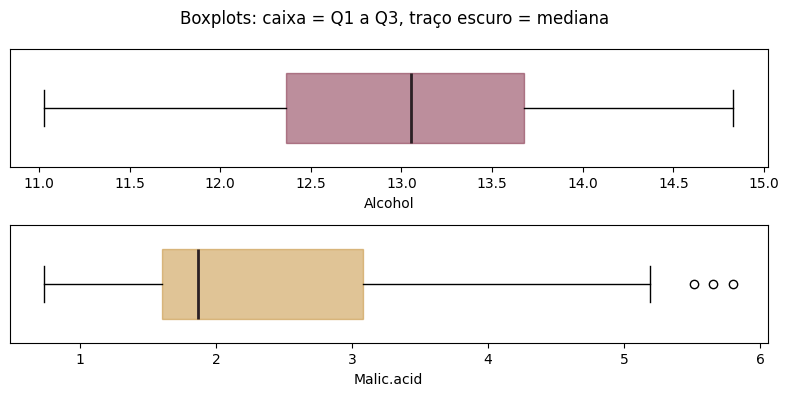

Alcohol: limites de Tukey = [10.39; 15.65] | valores atípicos: 0 []
Malic.acid: limites de Tukey = [-0.62; 5.30] | valores atípicos: 3 [5.51, 5.65, 5.8]


In [4]:
# ===== Quartis em gráfico (boxplot) e valores atípicos (regra de Tukey) =====
fig, axes = plt.subplots(2, 1, figsize=(8, 4))
for ax, col in zip(axes, ['Alcohol', 'Malic.acid']):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')   # 'vert' foi renomeado em versões novas do matplotlib
        bp = ax.boxplot(df[col], vert=False, widths=0.6, patch_artist=True,
                        medianprops=dict(color=COR_TRACO, linewidth=2))
    bp['boxes'][0].set(facecolor=CORES[col], alpha=0.5, edgecolor=CORES[col])
    ax.set_yticks([])
    ax.set_xlabel(col)
plt.suptitle('Boxplots: caixa = Q1 a Q3, traço escuro = mediana')
plt.tight_layout()
plt.show()

for col in ['Alcohol', 'Malic.acid']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = df.loc[(df[col] < lim_inf) | (df[col] > lim_sup), col]
    print(f'{col}: limites de Tukey = [{lim_inf:.2f}; {lim_sup:.2f}] | valores atípicos: {len(atipicos)}', sorted(atipicos.tolist()))

# Interpretação: em Alcohol a mediana fica no meio da caixa e não há valores atípicos. Em
# Malic.acid a mediana está colada em Q1, a caixa se estende para a direita e 3 vinhos
# (5,51; 5,65; 5,80) ficam acima do limite de Tukey (5,30): outra evidência da cauda à direita.

### Interpretação da análise descritiva

O coeficiente de variação de **Alcohol** é aproximadamente **6,24%**, indicando baixa dispersão relativa. Já **Malic.acid** apresenta coeficiente de variação próximo de **47,82%**, mostrando muito mais heterogeneidade. O desvio padrão absoluto (0,81 contra 1,12) subestima essa diferença, porque as escalas das variáveis são distintas; por isso o CV é a medida adequada para compará-las.

Os quartis reforçam o contraste: 50% dos valores de Alcohol ficam aproximadamente entre 12,36 e 13,68, enquanto 50% dos valores de Malic.acid ficam entre 1,60 e 3,08. Os coeficientes de assimetria (-0,05 e 1,04) e os boxplots confirmam o que os histogramas sugeriam: Alcohol é simétrica e sem valores atípicos, enquanto Malic.acid tem cauda à direita e 3 valores atípicos.

### 1.3 (c) Análise probabilística: distribuição Normal e cálculos

In [5]:
# ===== (c) Distribuição de probabilidade: Normal com média e desvio padrão da amostra =====
# P(X > a)     = 1 - F(a)
# P(a < X < b) = F(b) - F(a),  em que F = função de distribuição acumulada (norm.cdf)
# Cada probabilidade teórica é comparada com a frequência empírica (proporção real no dataset).
def prob_normal_e_empirica(serie, tipo, a, b=None):
    mu, sigma = serie.mean(), serie.std()
    if tipo == 'acima':
        p_normal = 1 - norm.cdf(a, loc=mu, scale=sigma)
        p_emp = (serie > a).mean()
    else:
        p_normal = norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)
        p_emp = ((serie > a) & (serie < b)).mean()
    return p_normal, p_emp

resultados_prob = []
for var, descricao, tipo, a, b in [
    ('Alcohol', 'P(X > 13,5)', 'acima', 13.5, None),
    ('Alcohol', 'P(12,5 < X < 14,0)', 'entre', 12.5, 14.0),
    ('Malic.acid', 'P(X > 3,0)', 'acima', 3.0, None),
    ('Malic.acid', 'P(1,5 < X < 2,5)', 'entre', 1.5, 2.5),
]:
    pn, pe = prob_normal_e_empirica(df[var], tipo, a, b)
    resultados_prob.append([var, descricao, pn, pe])

probabilidades = pd.DataFrame(resultados_prob, columns=['Variável', 'Cálculo', 'Prob. normal', 'Freq. empírica'])
probabilidades['Prob. normal (%)'] = probabilidades['Prob. normal'] * 100
probabilidades['Freq. empírica (%)'] = probabilidades['Freq. empírica'] * 100
probabilidades['Diferença (p.p.)'] = (probabilidades['Prob. normal (%)'] - probabilidades['Freq. empírica (%)']).abs()
display(probabilidades[['Variável', 'Cálculo', 'Prob. normal (%)', 'Freq. empírica (%)', 'Diferença (p.p.)']].round(2))

# Interpretação de cada cálculo (Normal x dados reais):
#  - Alcohol P(X > 13,5): 26,92% x 30,90% -> a Normal subestima a cauda em 4,0 p.p.
#  - Alcohol P(12,5 < X < 14,0): 62,21% x 55,62% -> a Normal superestima o miolo em 6,6 p.p.
#    (ajuste razoável: diferenças de 4 a 7 p.p. para uma variável concentrada e simétrica).
#  - Malic.acid P(X > 3,0): 27,62% x 26,40% -> cauda bem aproximada (1,2 p.p.).
#  - Malic.acid P(1,5 < X < 2,5): 33,12% x 46,07% -> a Normal subestima o miolo em cerca de
#    13 p.p.: os dados se acumulam abaixo de 1,9, mas a Normal é simétrica em torno da média.

,Variável,Cálculo,Prob. normal (%),Freq. empírica (%),Diferença (p.p.)
0,Alcohol,"P(X > 13,5)",26.92,30.90,3.98
1,Alcohol,"P(12,5 < X < 14,0)",62.21,55.62,6.59
2,Malic.acid,"P(X > 3,0)",27.62,26.40,1.22
3,Malic.acid,"P(1,5 < X < 2,5)",33.12,46.07,12.95


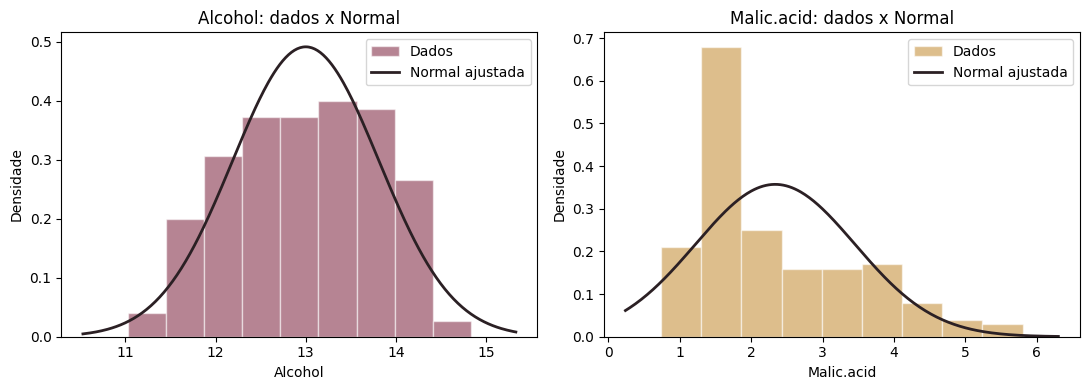

In [6]:
# ===== Curva Normal ajustada sobre os histogramas (densidade) =====
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ['Alcohol', 'Malic.acid']):
    s = df[col]
    ax.hist(s, bins=9, density=True, color=CORES[col], alpha=0.55, edgecolor='white', label='Dados')
    x = np.linspace(s.min() - 0.5, s.max() + 0.5, 300)
    ax.plot(x, norm.pdf(x, s.mean(), s.std()), color=COR_TRACO, linewidth=2, label='Normal ajustada')
    ax.set_title(f'{col}: dados x Normal')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidade')
    ax.legend()
plt.tight_layout()
plt.show()

# Interpretação: em Alcohol a curva acompanha o formato de sino dos dados; em Malic.acid o pico
# dos dados fica à esquerda da média e a cauda direita é mais longa, por isso a Normal não encaixa.

### Interpretação probabilística

A distribuição Normal foi utilizada como **aproximação teórica**, com a média e o desvio padrão da própria amostra, e cada probabilidade foi comparada com a frequência real do dataset.

- **Alcohol:** ajuste razoável. Subestima a cauda P(X > 13,5) em 4,0 p.p. e superestima o intervalo central em 6,6 p.p. A distribuição é concentrada e simétrica, o que favorece a Normal.
- **Malic.acid:** a cauda P(X > 3,0) fica próxima do observado (1,2 p.p.), mas o intervalo central P(1,5 < X < 2,5) é fortemente subestimado: 33,12% pela Normal contra 46,07% nos dados (cerca de 13 p.p.). A causa é a **assimetria à direita**: os dados se acumulam à esquerda da média, e a Normal distribui a massa de forma simétrica.

Conclusão: a Normal é uma aproximação aceitável para Alcohol e limitada para Malic.acid, para a qual uma distribuição assimétrica seria mais adequada. Não foi aplicado teste formal de normalidade; a avaliação foi feita por comparação direta com as frequências observadas.

## 2. Machine Learning & Modelling - K-means

### 2.1 Introdução: problema e solução proposta
**Problema:** temos 178 vinhos descritos por 13 medidas químicas e queremos descobrir quais são mais parecidos entre si, formando grupos com perfis distintos, **sem usar a classe original como resposta** (aprendizado não supervisionado).

**Solução proposta:** aplicar o **K-means**, algoritmo que forma grupos minimizando a distância dos registros aos centróides, em quatro passos: (1) pré-processamento (remover a classe, tratar nulos e padronizar); (2) escolha do número de grupos *k* com Elbow e Silhouette; (3) ajuste do K-means final; (4) análise do perfil químico de cada grupo (teor alcoólico, acidez, cinza etc.).

### 2.2 Pré-processamento
A coluna **Wine** é removida porque identifica a classe original e não deve participar da descoberta dos grupos. Em seguida, verificamos valores nulos e padronizamos as variáveis com `StandardScaler`, pois o K-means é sensível à escala das features (por exemplo, Proline está na casa dos milhares e Hue em torno de 1).

As outras 12 variáveis químicas foram mantidas, pois todas descrevem o perfil do vinho e nenhuma é identificador ou rótulo. Como não há valores nulos, não foi necessária nenhuma imputação.

In [7]:
# ===== Pré-processamento =====
X = df.drop(columns=['Wine'])    # remove a classe original: o agrupamento não pode "ver" a resposta
print('Quantidade de valores nulos:', X.isnull().sum().sum())
print('Features utilizadas:', X.shape[1])

# Padronização (média 0 e desvio padrão 1): evita que variáveis de escala grande dominem a distância
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Média aproximada após padronização:', np.round(X_scaled.mean(axis=0).mean(), 6))
print('Desvio padrão médio após padronização:', np.round(X_scaled.std(axis=0).mean(), 6))

Quantidade de valores nulos: 0
Features utilizadas: 13
Média aproximada após padronização: -0.0
Desvio padrão médio após padronização: 1.0


### 2.3 Escolha do número de clusters: Elbow e Silhouette

Testamos valores de `k` entre 2 e 8. O método Elbow avalia a redução da inércia e o Silhouette Score mede o quão bem separados e coesos estão os grupos.

,k,Inércia,Silhouette
0,2,1658.7589,0.2593
1,3,1277.9285,0.2849
2,4,1175.4283,0.2602
3,5,1109.5127,0.2016
4,6,1046.0023,0.2372
5,7,981.5952,0.2036
6,8,935.2012,0.1570


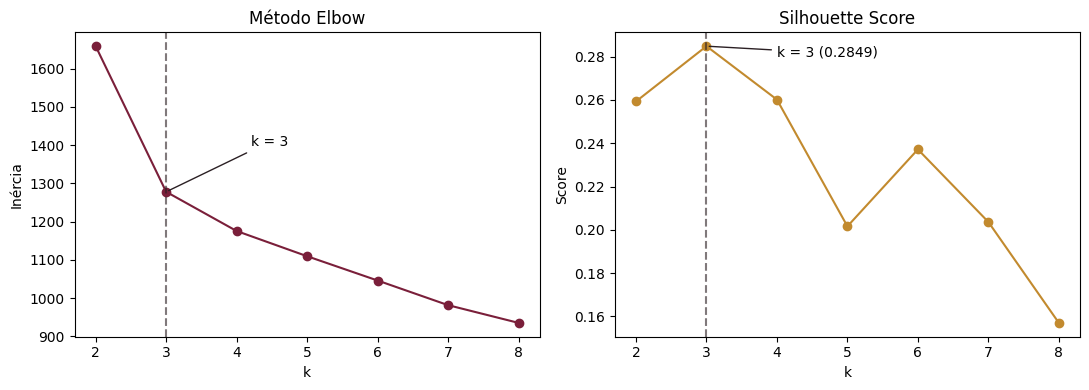

In [8]:
# ===== Elbow (inércia) e Silhouette para k = 2..8 =====
ks = range(2, 9)
inercias = []
silhuetas = []

for k in ks:
    # random_state fixo + n_init = 10 -> resultado reproduzível e estável
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_scaled)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels))

comparacao_k = pd.DataFrame({'k': list(ks), 'Inércia': inercias, 'Silhouette': silhuetas})
display(comparacao_k.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inercias, marker='o', color=CORES['Alcohol'])
axes[0].set_title('Método Elbow')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inércia')
axes[0].set_xticks(list(ks))
axes[1].plot(list(ks), silhuetas, marker='o', color=CORES['Malic.acid'])
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].set_xticks(list(ks))
for ax in axes:
    ax.axvline(3, color=COR_TRACO, linestyle='--', alpha=0.6)   # k escolhido
axes[0].annotate('k = 3', (3, inercias[1]), xytext=(4.2, inercias[1] + 120), arrowprops=dict(arrowstyle='-', color=COR_TRACO))
axes[1].annotate(f'k = 3 ({silhuetas[1]:.4f})', (3, silhuetas[1]), xytext=(4.0, silhuetas[1] - 0.005), arrowprops=dict(arrowstyle='-', color=COR_TRACO))
plt.tight_layout()
plt.show()

# Interpretação: a inércia cai forte de k = 2 (1658,76) para k = 3 (1277,93) e depois cai
# menos (cotovelo em k = 3). O Silhouette é máximo em k = 3 (0,2849). Os dois critérios
# concordam em k = 3.

O maior **Silhouette Score** ocorre em **k = 3** (aproximadamente **0,2849**). O gráfico do Elbow também mostra uma queda forte de inércia até a região de três grupos. Portanto, adotamos **3 clusters** como solução final. O valor do Silhouette é modesto, o que indica grupos com alguma sobreposição.

### 2.4 Ajuste final do K-means e análise dos grupos

In [9]:
# ===== Ajuste final (k = 3) e perfil dos clusters =====
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster = df.copy()
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

contagens = df_cluster['Cluster'].value_counts().sort_index()
medias = df_cluster.groupby('Cluster').mean(numeric_only=True)   # médias na escala original
perfil = medias[['Alcohol', 'Malic.acid', 'Ash', 'Phenols', 'Flavanoids', 'Color.int', 'Hue', 'Proline']].copy()
perfil.insert(0, 'n', contagens)
display(perfil.round(2))

# ----- Respostas às perguntas do enunciado (item e) -----
print('Teor alcoólico médio de cada grupo:')
for c, v in perfil['Alcohol'].items():
    print(f'  Cluster {c}: {v:.2f}')
mais_acido = perfil['Malic.acid'].idxmax()
print(f"\nGrupo com vinhos mais ácidos (maior Malic.acid médio): Cluster {mais_acido} ({perfil.loc[mais_acido, 'Malic.acid']:.2f})")
print('\nCinza (Ash) média de cada grupo:')
for c, v in perfil['Ash'].items():
    print(f'  Cluster {c}: {v:.2f}')

# Interpretação: Cluster 0 (65) = menor álcool, cor mais clara e menor Proline; Cluster 1 (51) =
# maior Malic.acid e maior intensidade de cor; Cluster 2 (62) = maior álcool, Proline muito
# alto e mais fenóis/flavonoides.

,n,Alcohol,Malic.acid,Ash,Phenols,Flavanoids,Color.int,Hue,Proline
Cluster,,,,,,,,,
0,65,12.25,1.90,2.23,2.25,2.05,2.97,1.06,510.17
1,51,13.13,3.31,2.42,1.68,0.82,7.23,0.69,619.06
2,62,13.68,2.00,2.47,2.85,3.00,5.45,1.07,1100.23


Teor alcoólico médio de cada grupo:
  Cluster 0: 12.25
  Cluster 1: 13.13
  Cluster 2: 13.68

Grupo com vinhos mais ácidos (maior Malic.acid médio): Cluster 1 (3.31)

Cinza (Ash) média de cada grupo:
  Cluster 0: 2.23
  Cluster 1: 2.42
  Cluster 2: 2.47


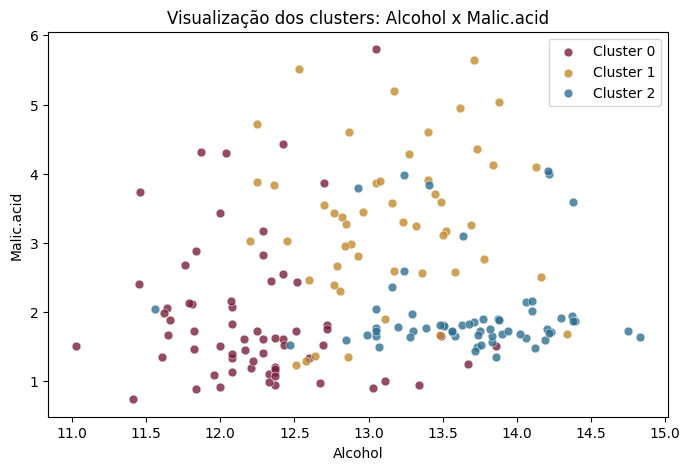

In [10]:
# ===== Clusters no plano Alcohol x Malic.acid =====
cores_cluster = ['#7A1F3A', '#C28A2E', '#2F6F8F']
plt.figure(figsize=(8, 5))
for c in sorted(df_cluster['Cluster'].unique()):
    grupo = df_cluster[df_cluster['Cluster'] == c]
    plt.scatter(grupo['Alcohol'], grupo['Malic.acid'], s=40, alpha=0.8, color=cores_cluster[c],
                edgecolor='white', linewidth=0.4, label=f'Cluster {c}')
plt.title('Visualização dos clusters: Alcohol x Malic.acid')
plt.xlabel('Alcohol')
plt.ylabel('Malic.acid')
plt.legend()
plt.show()

# Interpretação: neste plano de apenas 2 variáveis os grupos se sobrepõem em parte (o K-means usa as
# 13 variáveis), mas já se nota o Cluster 1 acima (mais Malic.acid) e o Cluster 2 à direita (mais álcool).

### Análise dos grupos (item e)

**Qual o teor alcoólico dos vinhos de cada grupo?** Cluster 0: **12,25** (o menor); Cluster 1: **13,13** (intermediário); Cluster 2: **13,68** (o maior).

**Qual o grupo com vinhos mais ácidos?** O **Cluster 1**, com `Malic.acid` médio de **3,31**, contra 1,90 (Cluster 0) e 2,00 (Cluster 2). O ácido málico é usado como referência de acidez, já que o dataset não traz pH.

**O que diferencia um grupo do outro?**

- **Cluster 0 (65 vinhos), perfil leve:** menor teor alcoólico (12,25), cor mais clara (`Color.int` 2,97), menor Proline (510) e menor cinza (`Ash` 2,23).
- **Cluster 1 (51 vinhos), perfil ácido e colorido:** mais ácido (3,31), cor mais intensa (7,23), `Hue` mais baixo (0,69), menos fenóis (1,68) e menos flavonoides (0,82), com álcool intermediário (13,13).
- **Cluster 2 (62 vinhos), perfil alcoólico e encorpado:** maior teor alcoólico (13,68), Proline muito mais alto (1100), mais fenóis (2,85) e flavonoides (3,00), maior cinza (2,47) e acidez baixa (2,00).

A cinza (`Ash`) separa pouco os grupos (2,23 a 2,47); Proline, intensidade de cor e flavonoides diferenciam muito mais. No gráfico Alcohol x Malic.acid há sobreposição entre os grupos, o que é esperado, já que o agrupamento usa as 13 variáveis e não apenas essas duas.

## 3. Conclusão

A análise estatística mostrou que **Alcohol** é uma variável homogênea e aproximadamente simétrica (CV de 6,24%), enquanto **Malic.acid** possui dispersão bem maior (CV de 47,82%), assimetria à direita e valores atípicos. A distribuição Normal aproxima razoavelmente Alcohol e é limitada para Malic.acid. Na etapa de Machine Learning, a padronização foi necessária para tornar as escalas comparáveis. Os métodos Elbow e Silhouette sustentaram a escolha de **k = 3**, e os três clusters apresentaram diferenças claras em álcool, ácido málico, intensidade de cor, compostos fenólicos e Proline.

Dessa forma, o trabalho integra análise estatística, probabilidade, pré-processamento e clusterização de maneira consistente com o objetivo proposto.

### Limitações e próximos passos
- Não foi aplicado teste formal de normalidade (a avaliação foi comparativa).
- A análise estatística cobre apenas duas variáveis.
- O Silhouette moderado (0,2849) sugere sobreposição entre os clusters.
- Próximos passos: testes de normalidade, distribuições assimétricas para Malic.acid e comparação dos clusters com a classe original (`Wine`) para validar o agrupamento.